In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import polars as pl
from preprocess_dataset_for_training import create_training_data
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import copy

In [2]:
# -------------------------------
# Reproducibility setup
# -------------------------------
seed = 42  
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)  # if using multi-GPU

# For deterministic behavior (slower but exact reproducibility)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# -------------------------------
# Device configuration
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# -------------------------------
# Load and preprocess data
# -------------------------------
file = "joined_df_with_weather"
joined_df = pl.read_parquet(f"./data/{file}.parquet")
X, y = create_training_data(joined_df)

In [5]:
X_np = X.to_numpy()
y_np = y.to_numpy()  # shape: (samples, 15 targets)
del joined_df, X
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, shuffle=False)
del X_np, y_np

# Feature scaling
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# Target scaling (important for stable float32 regression)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# Convert to PyTorch tensors on CPU (we'll move batches to GPU)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
del X_train, X_test, y_train, y_test

# -------------------------------
# DataLoaders for batching
# -------------------------------
batch_size = 256  
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -------------------------------
# Define multi-output NN
# -------------------------------
class MultiOutputNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_t.shape[1]
output_dim = y_train_t.shape[1]


def smape(y_true, y_pred, eps=1e-8):
    denom = (np.abs(y_true) + np.abs(y_pred)) + eps
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom, axis=0)

num_seeds = 100
num_targets = output_dim  # from existing cell
batch_size = 256

# containers
mae_all = np.zeros((num_seeds, num_targets))
rmse_all = np.zeros((num_seeds, num_targets))
r2_all = np.zeros((num_seeds, num_targets))
smape_all = np.zeros((num_seeds, num_targets))


In [6]:
import shap

# Train ONLY for seed = 42
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

model_42 = MultiOutputNN(input_dim, output_dim).to(device)
optimizer_42 = optim.Adam(model_42.parameters(), lr=1e-4)
criterion_42 = nn.HuberLoss(delta=1.0)

gen = torch.Generator().manual_seed(seed)
train_loader_42 = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, generator=gen)
test_loader_42 = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---- Train with Early Stopping (same logic as before) ----
best_val_loss = float("inf")
patience = 5
counter = 0
best_state = None
epochs = 100

for epoch in range(epochs):
    model_42.train()
    for xb, yb in train_loader_42:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_42.zero_grad()
        out = model_42(xb)
        loss = criterion_42(out, yb)
        loss.backward()
        optimizer_42.step()

    # Validation
    model_42.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader_42:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion_42(model_42(xb), yb).item() * xb.size(0)
    val_loss /= len(test_loader_42.dataset)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model_42.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            break

model_42.load_state_dict(best_state)
model_42.eval()


MultiOutputNN(
  (model): Sequential(
    (0): Linear(in_features=1635, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=15, bias=True)
  )
)

In [7]:
model_42.eval()
with torch.no_grad():
    out_demo = model_42(X_test_t[:1000].to(device))
print(out_demo.shape)  # should be (1000, 15)


torch.Size([1000, 15])


In [8]:
# -------------------------------
# Load and preprocess data
# -------------------------------
file = "joined_df_with_weather"
joined_df = pl.read_parquet(f"./data/{file}.parquet")
X, y = create_training_data(joined_df)

In [14]:
import torch
import shap
import numpy as np

# -------------------------------
# Parameters
# -------------------------------
N_demo = 2000        # number of test samples for SHAP
M_background = 200    # number of background samples for SHAP

# -------------------------------
# Subset test set
# -------------------------------
X_test_np_subset = X_test_t.numpy()

# -------------------------------
# Background samples
# -------------------------------
background = X_train_t[np.random.choice(len(X_train_t), M_background, replace=False)].to(device)

# -------------------------------
# DeepExplainer
# -------------------------------
explainer = shap.DeepExplainer(model_42, background)
shap_values = explainer.shap_values(X_test_t.to(device))

# -------------------------------
# Standardize shap_values shape
# -------------------------------
# Convert to list of arrays: shap_values_list[target] = (num_samples, num_features)
if isinstance(shap_values, np.ndarray):
    shap_values_list = [shap_values[:, :, t] for t in range(output_dim)]
else:
    shap_values_list = shap_values  # already a list

for t, sv in enumerate(shap_values_list):
    print(f"After conversion - Target {t} shap_values shape: {sv.shape}")
    assert sv.shape[0] == X_test_np_subset.shape[0], "Sample dimension mismatch"
    assert sv.shape[1] == X_test_np_subset.shape[1], "Feature dimension mismatch"


After conversion - Target 0 shap_values shape: (42064, 1635)
After conversion - Target 1 shap_values shape: (42064, 1635)
After conversion - Target 2 shap_values shape: (42064, 1635)
After conversion - Target 3 shap_values shape: (42064, 1635)
After conversion - Target 4 shap_values shape: (42064, 1635)
After conversion - Target 5 shap_values shape: (42064, 1635)
After conversion - Target 6 shap_values shape: (42064, 1635)
After conversion - Target 7 shap_values shape: (42064, 1635)
After conversion - Target 8 shap_values shape: (42064, 1635)
After conversion - Target 9 shap_values shape: (42064, 1635)
After conversion - Target 10 shap_values shape: (42064, 1635)
After conversion - Target 11 shap_values shape: (42064, 1635)
After conversion - Target 12 shap_values shape: (42064, 1635)
After conversion - Target 13 shap_values shape: (42064, 1635)
After conversion - Target 14 shap_values shape: (42064, 1635)



=== SHAP Summary Plot for Target Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


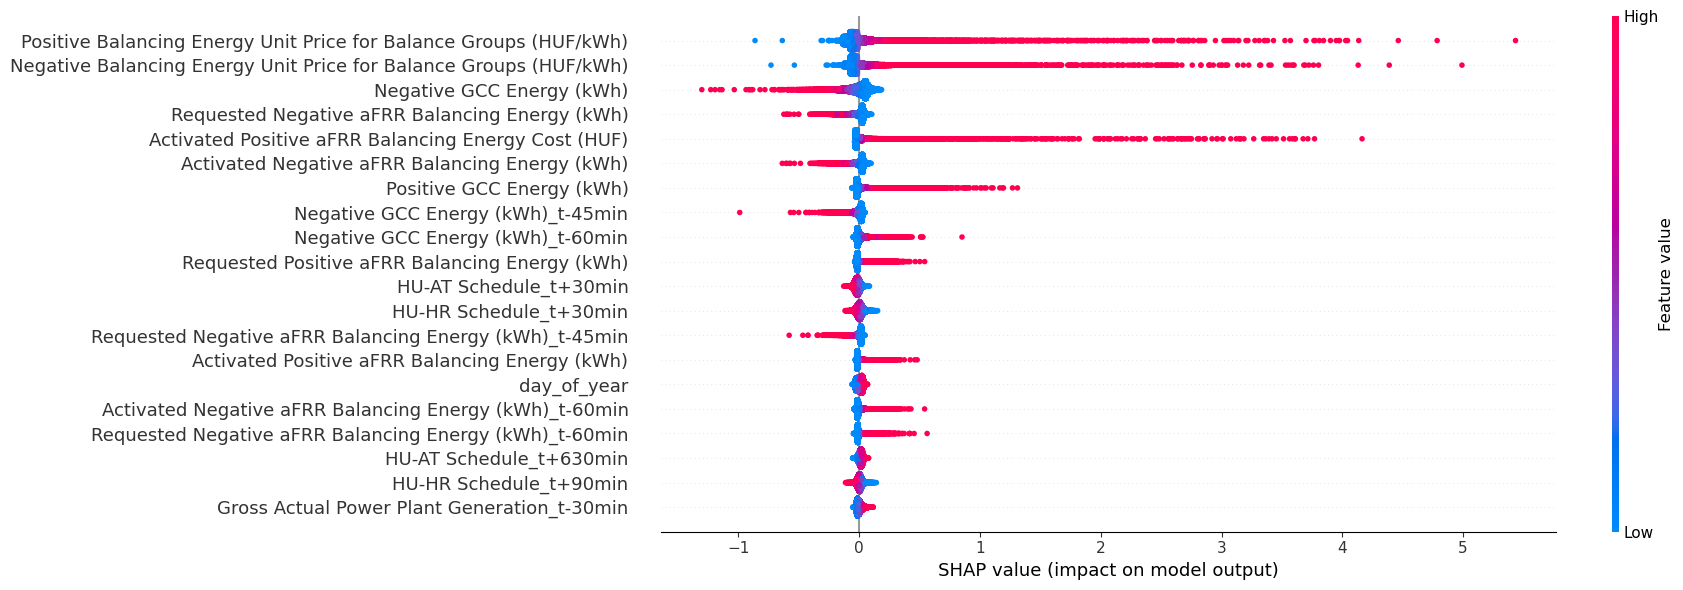


=== SHAP Summary Plot for Target Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


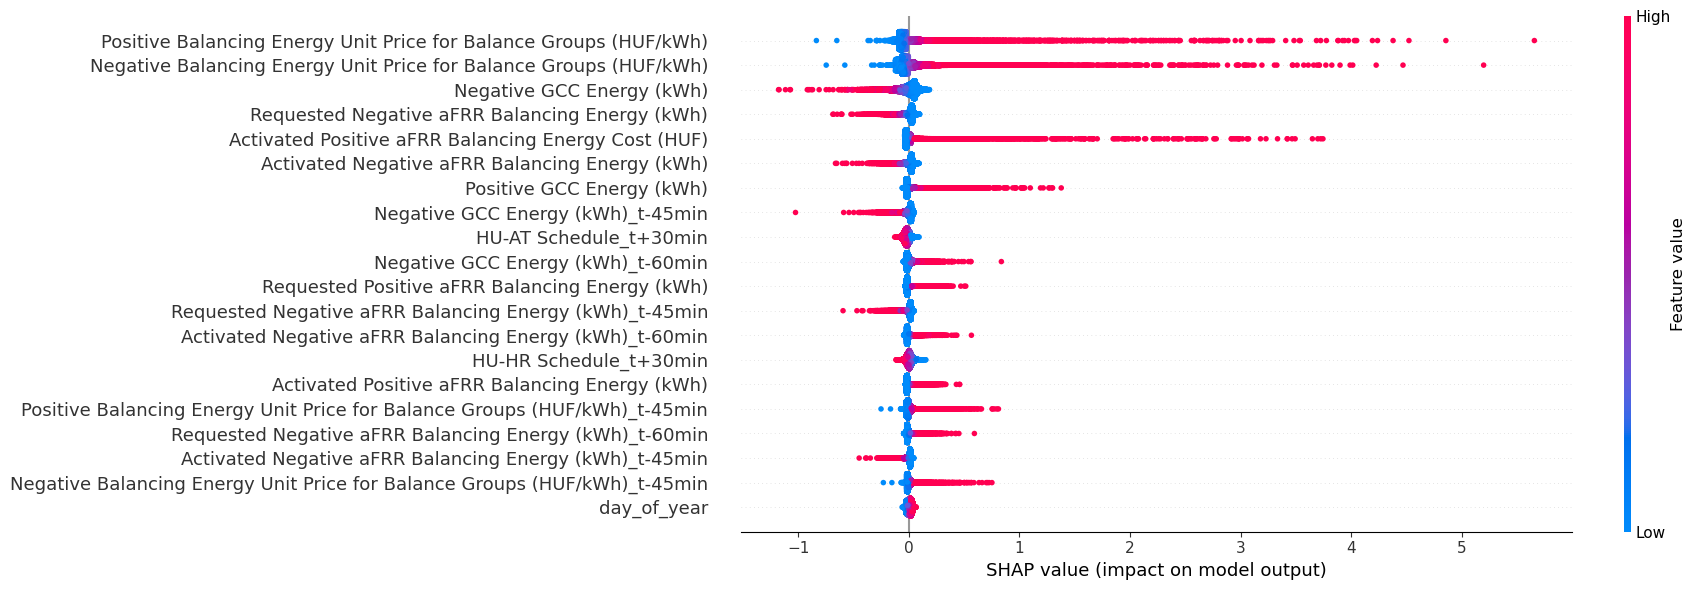


=== SHAP Summary Plot for Target System Direction (kWh)_t+15min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


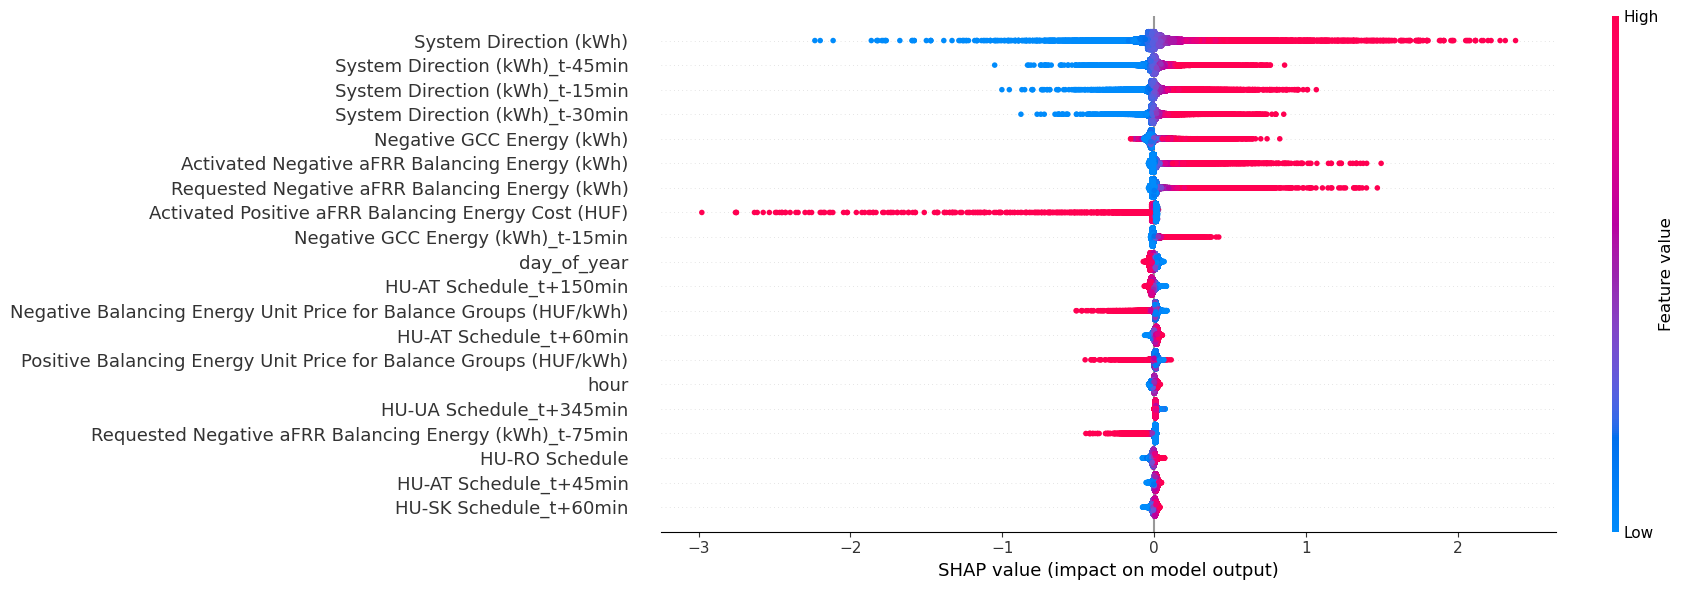


=== SHAP Summary Plot for Target Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+30min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


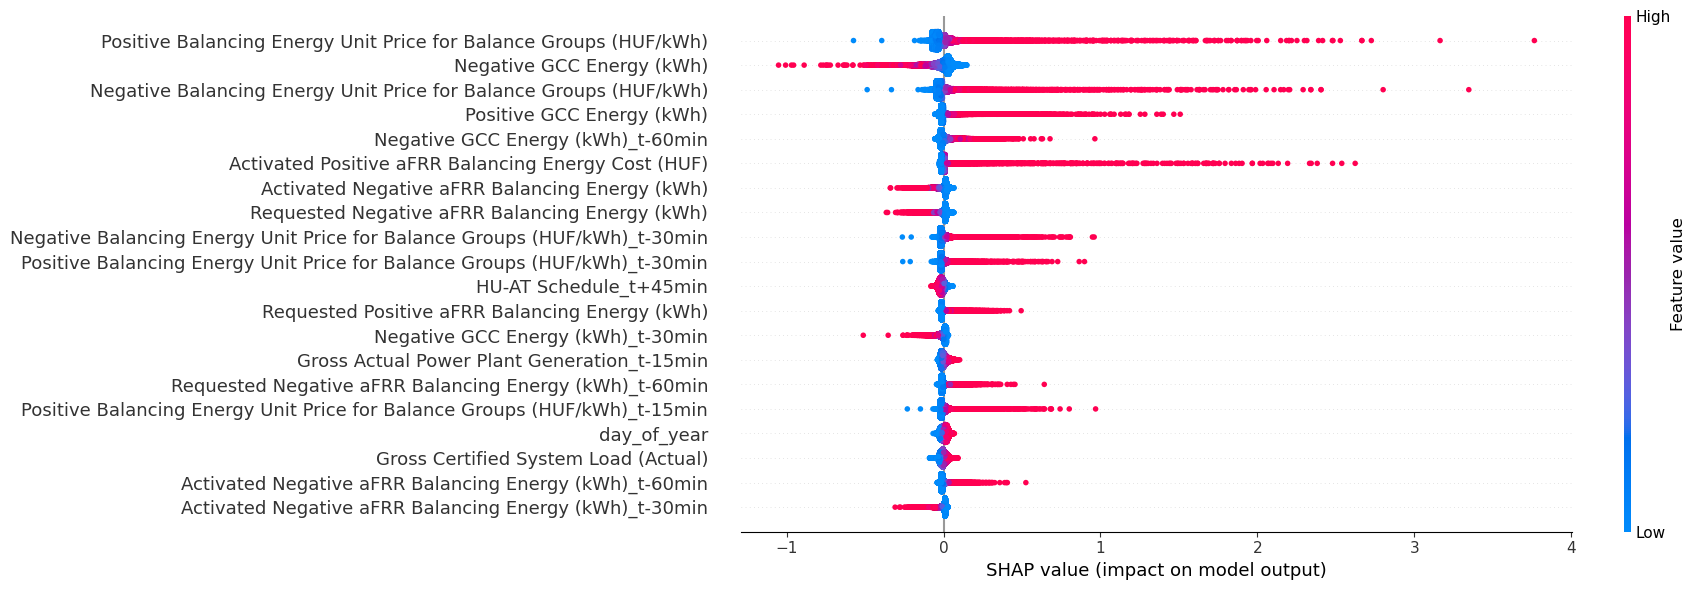


=== SHAP Summary Plot for Target Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+30min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


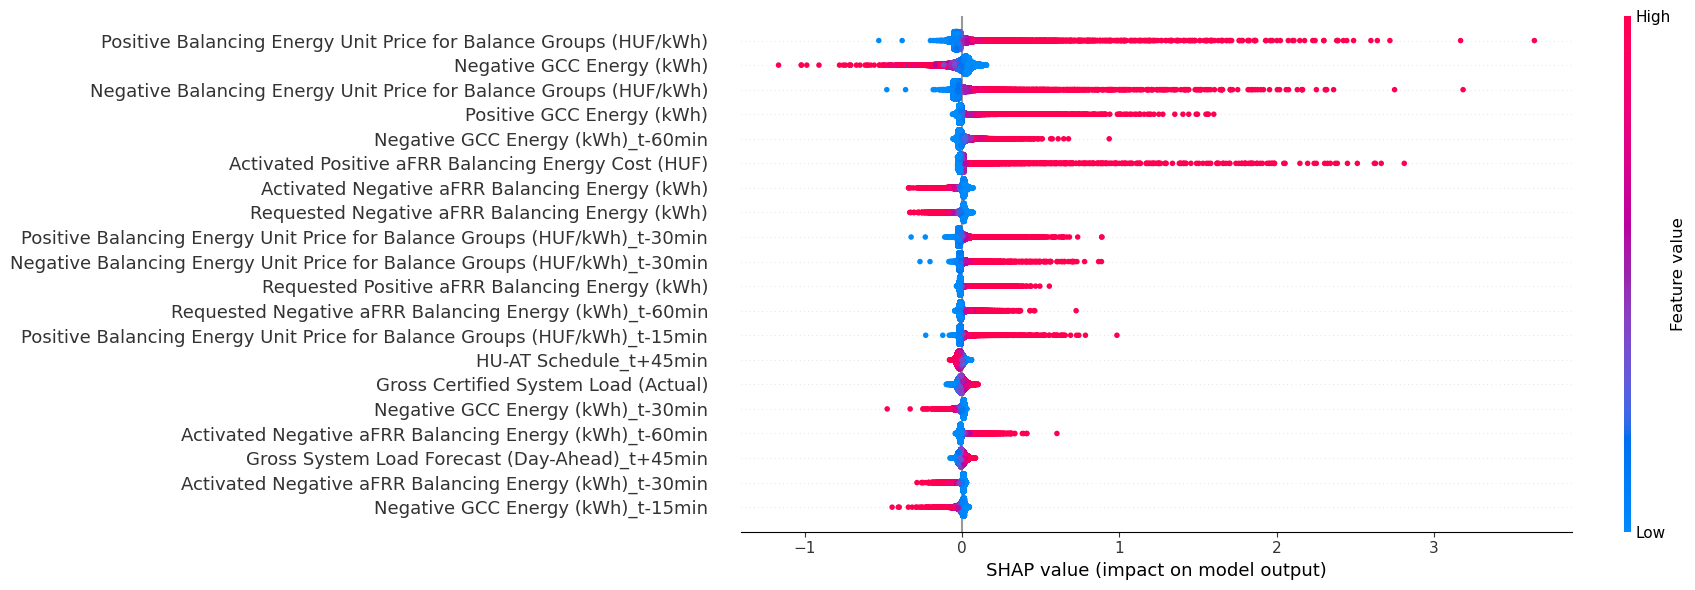


=== SHAP Summary Plot for Target System Direction (kWh)_t+30min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


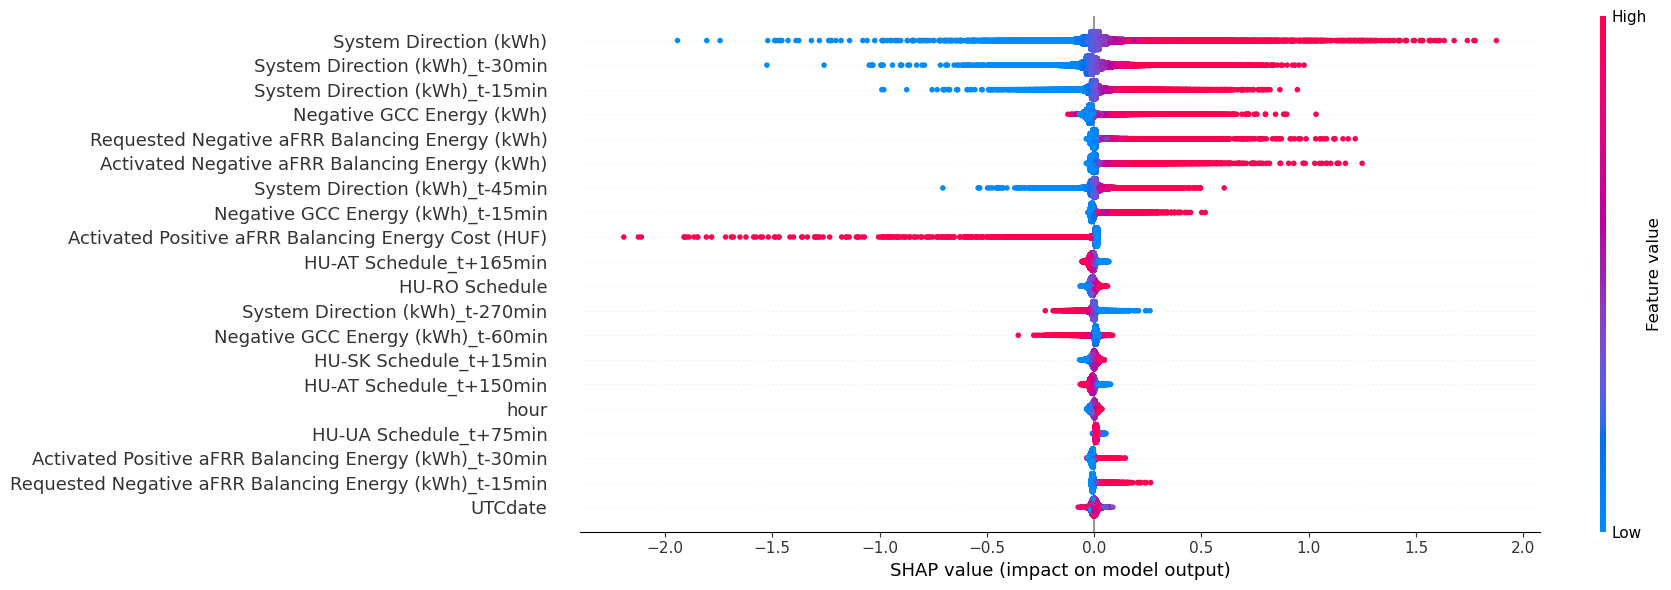


=== SHAP Summary Plot for Target Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+45min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


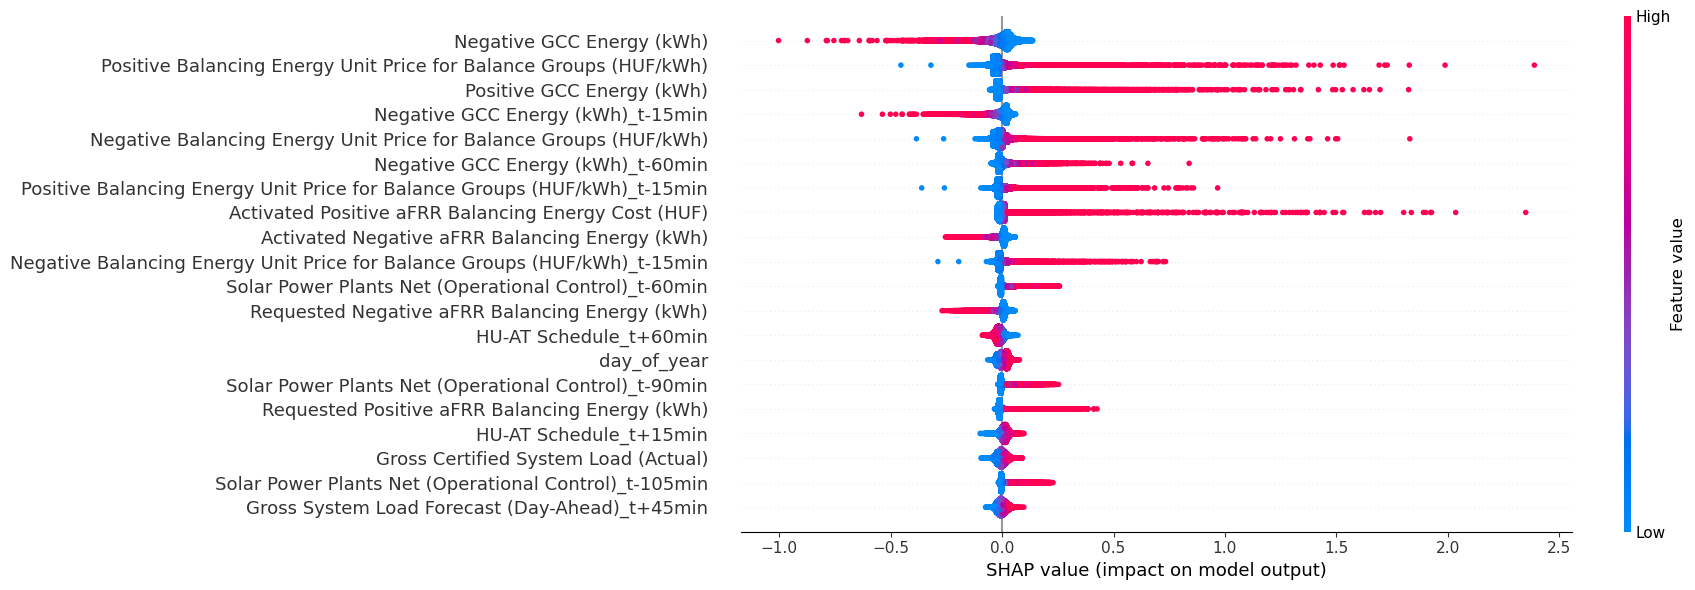


=== SHAP Summary Plot for Target Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+45min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


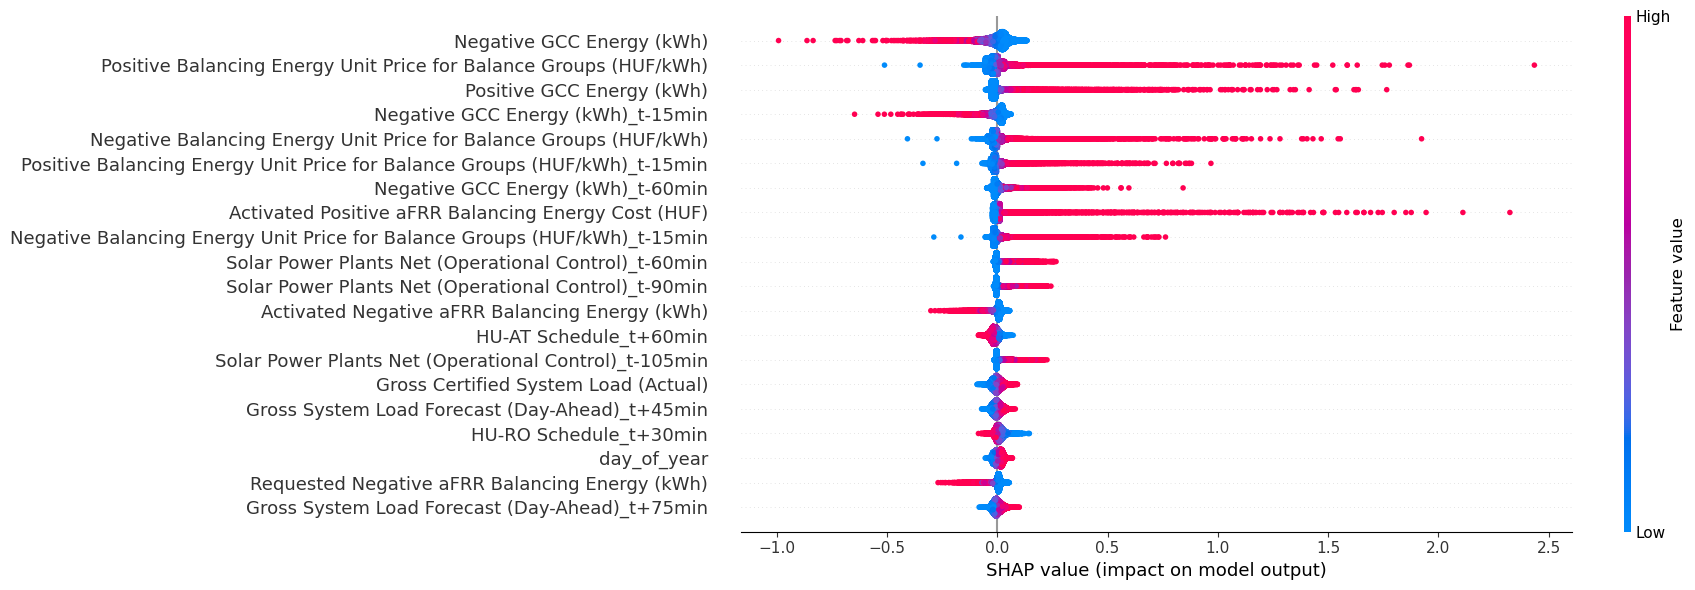


=== SHAP Summary Plot for Target System Direction (kWh)_t+45min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


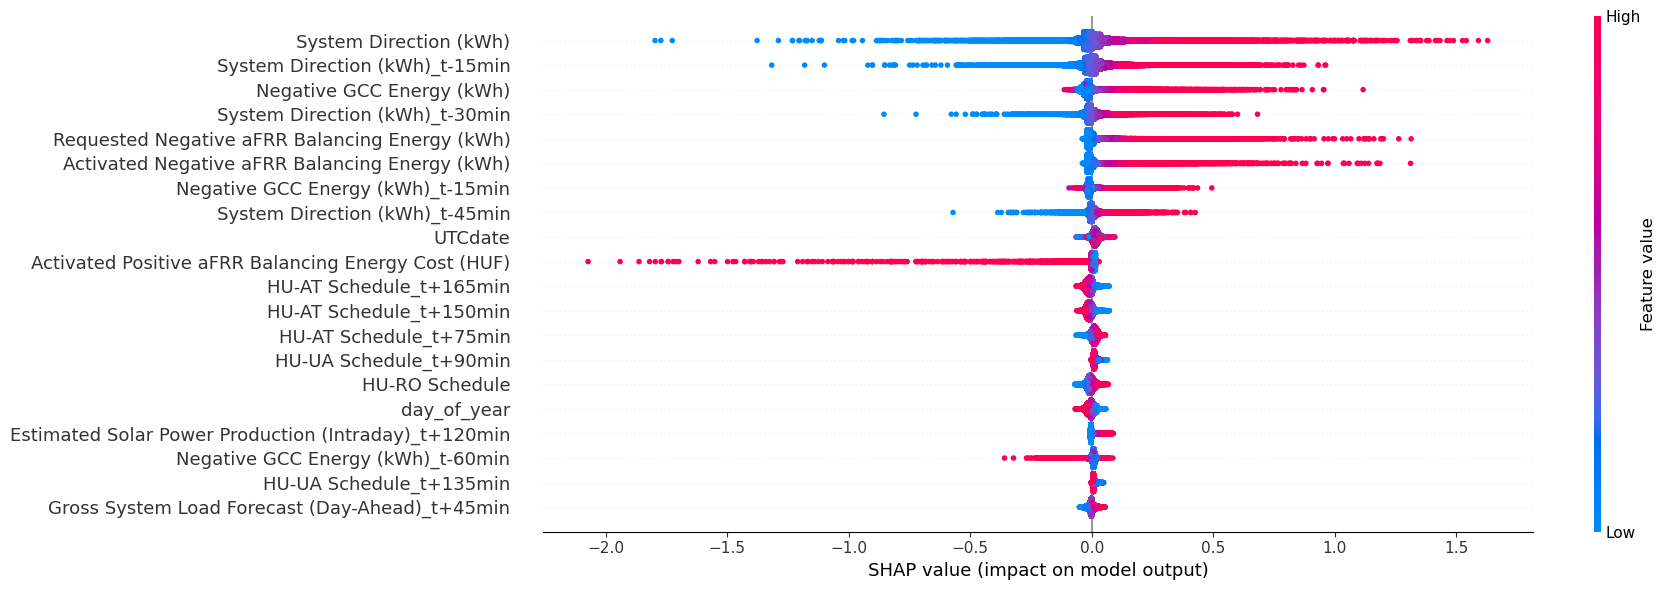


=== SHAP Summary Plot for Target Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+60min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


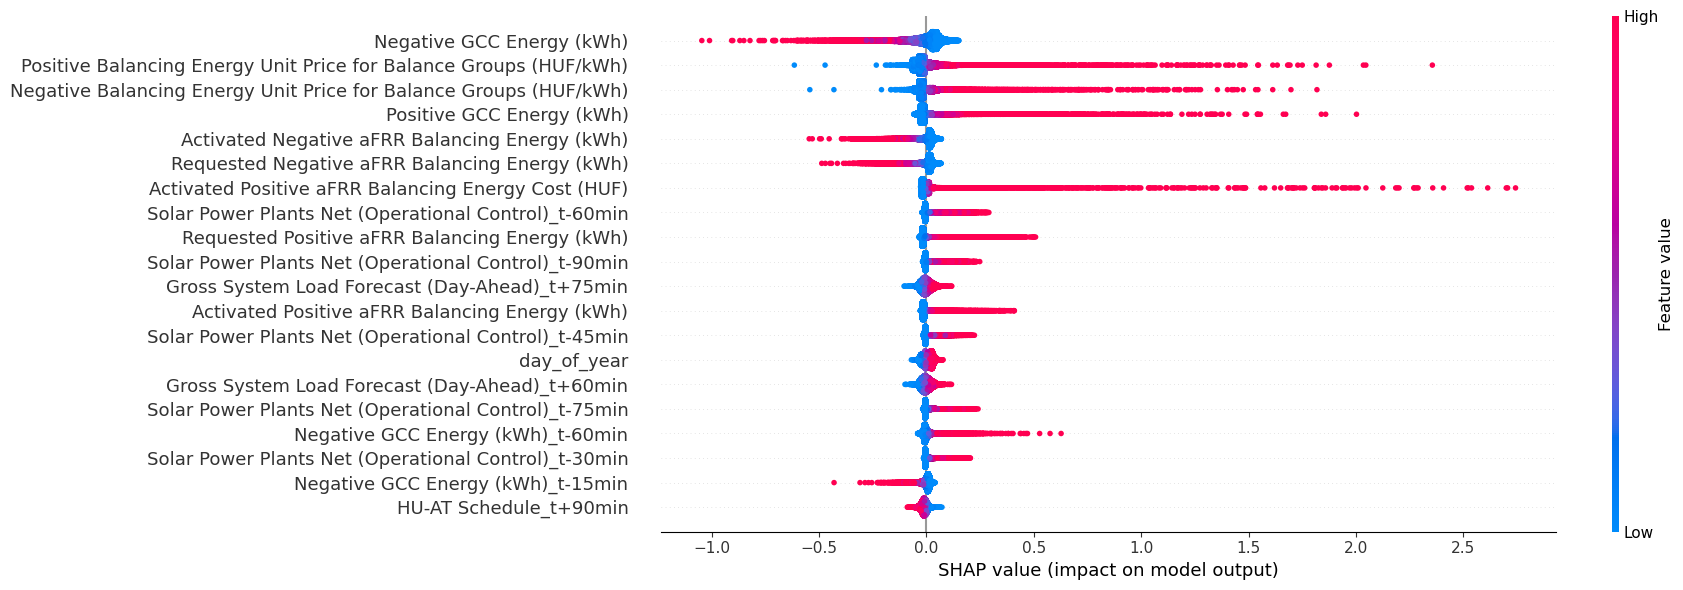


=== SHAP Summary Plot for Target Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+60min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


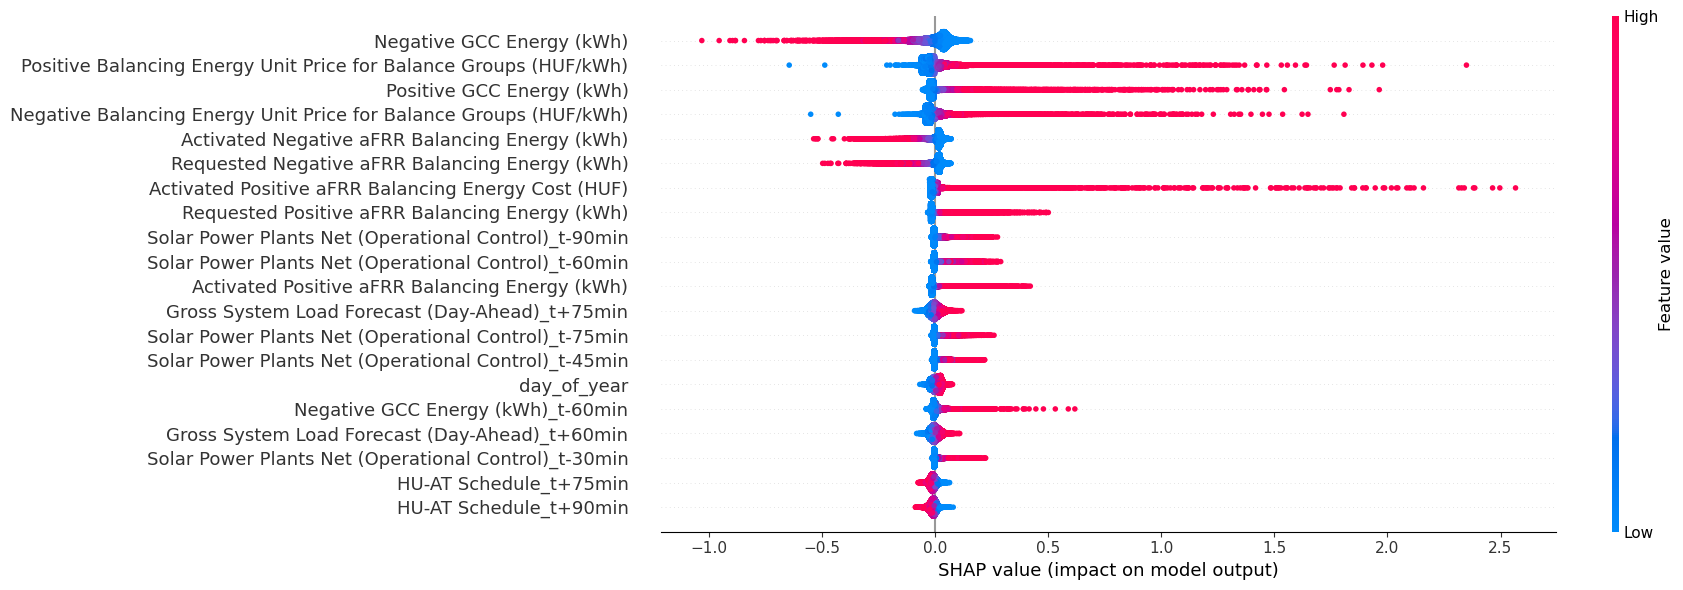


=== SHAP Summary Plot for Target System Direction (kWh)_t+60min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


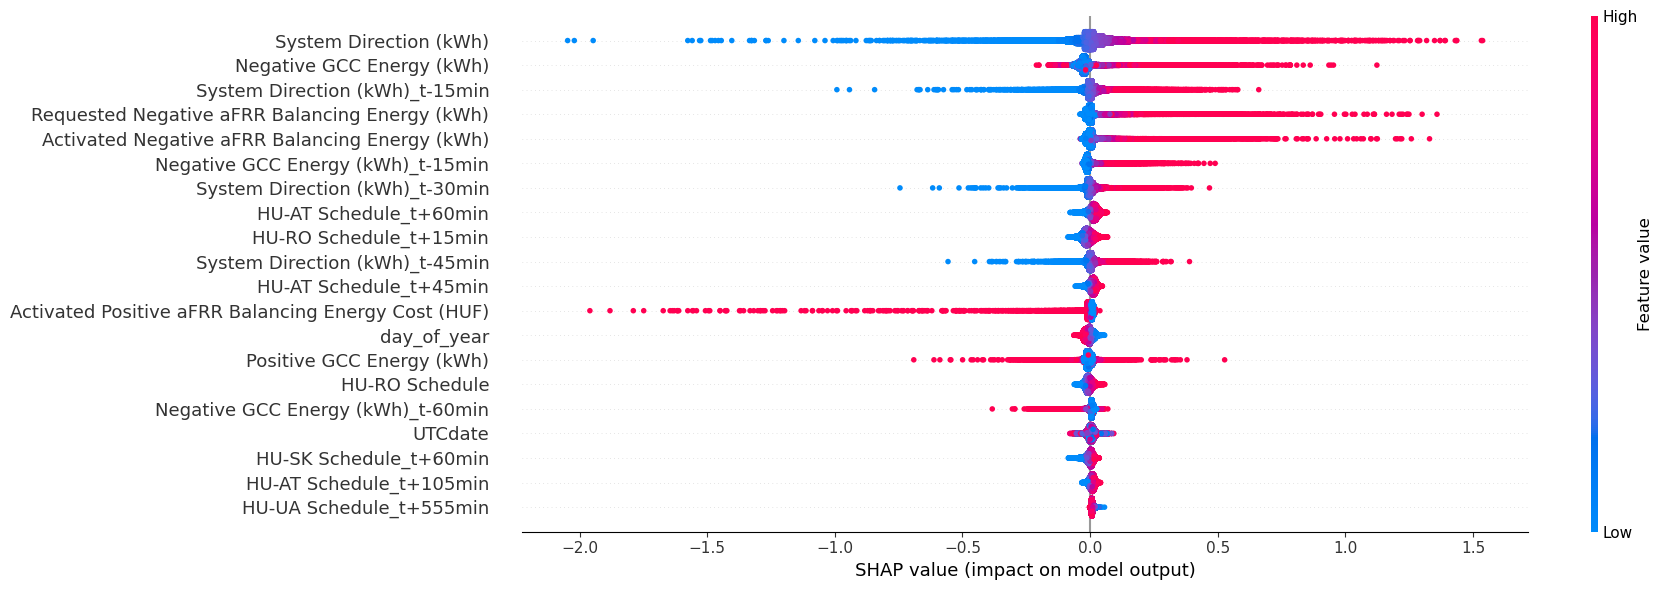


=== SHAP Summary Plot for Target Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+75min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


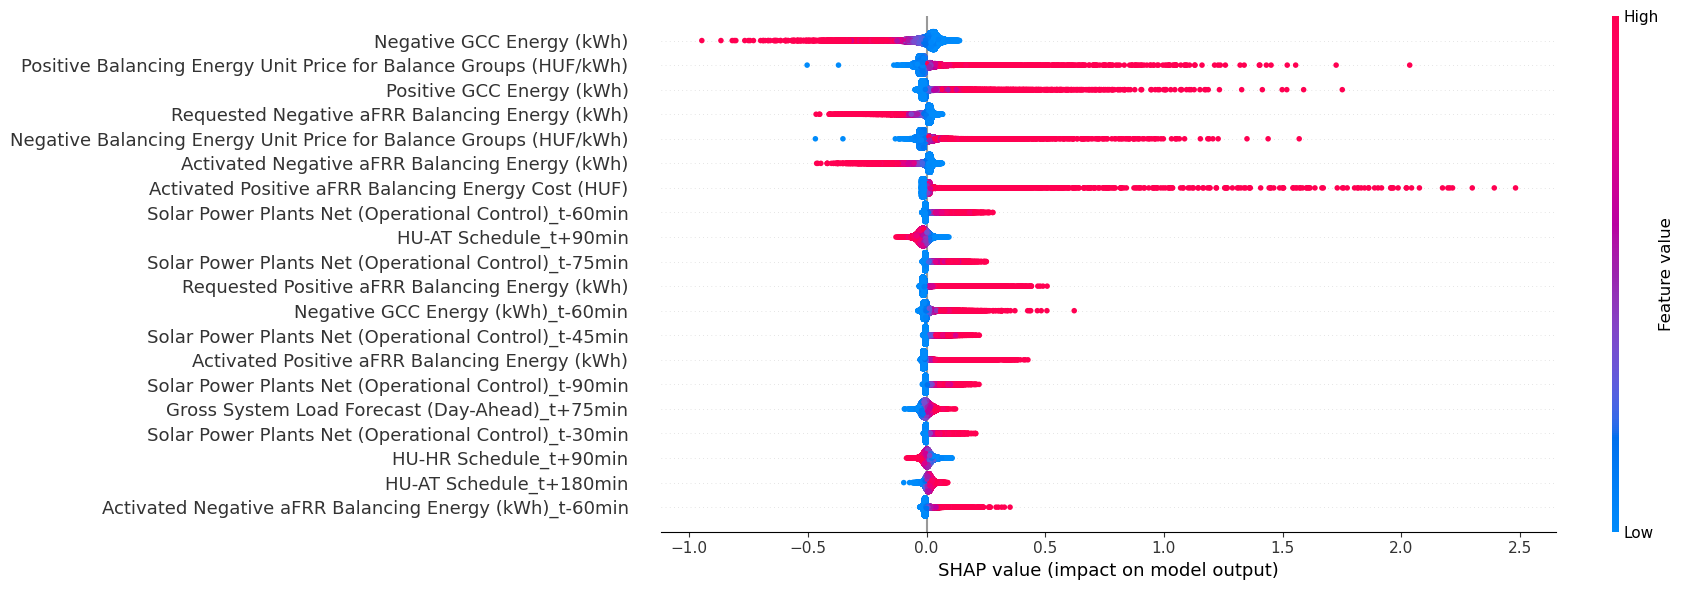


=== SHAP Summary Plot for Target Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+75min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


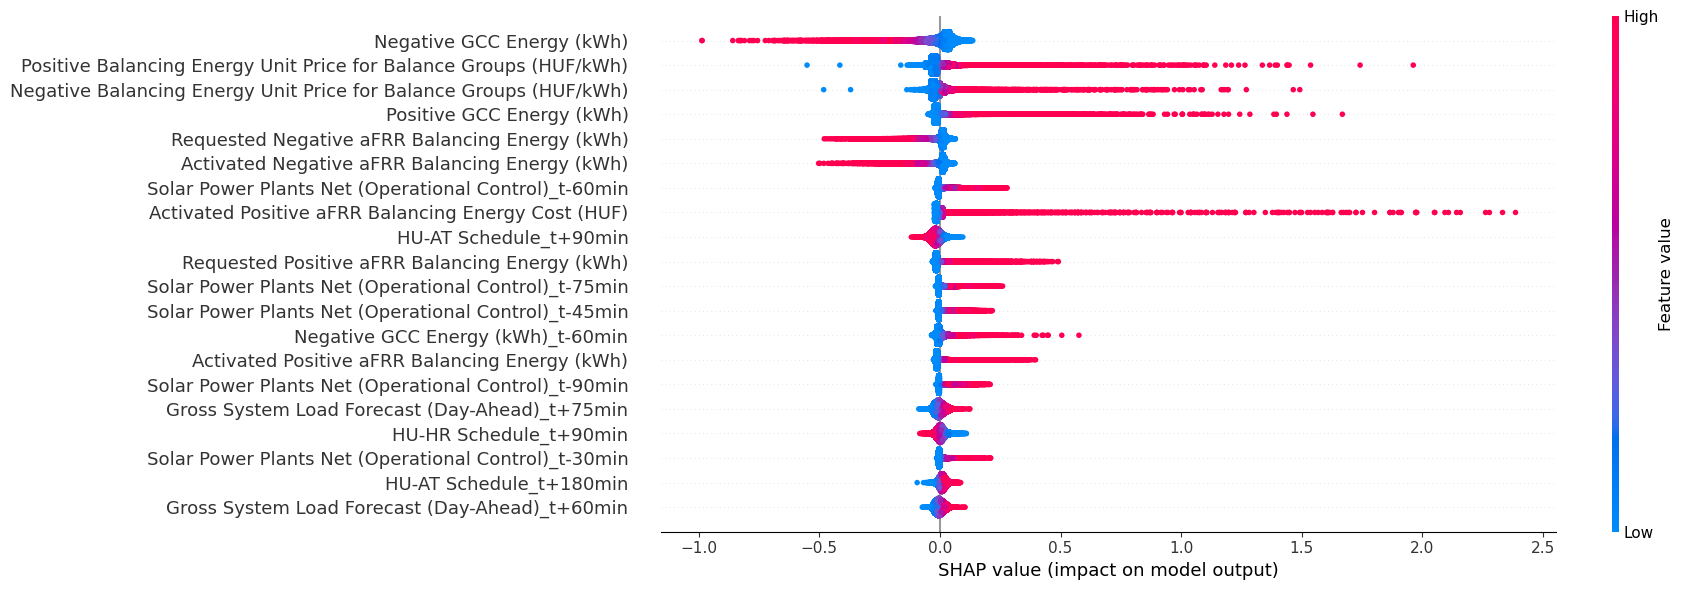


=== SHAP Summary Plot for Target System Direction (kWh)_t+75min ===


C:\Users\martin\AppData\Local\Temp\ipykernel_19016\3884133244.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


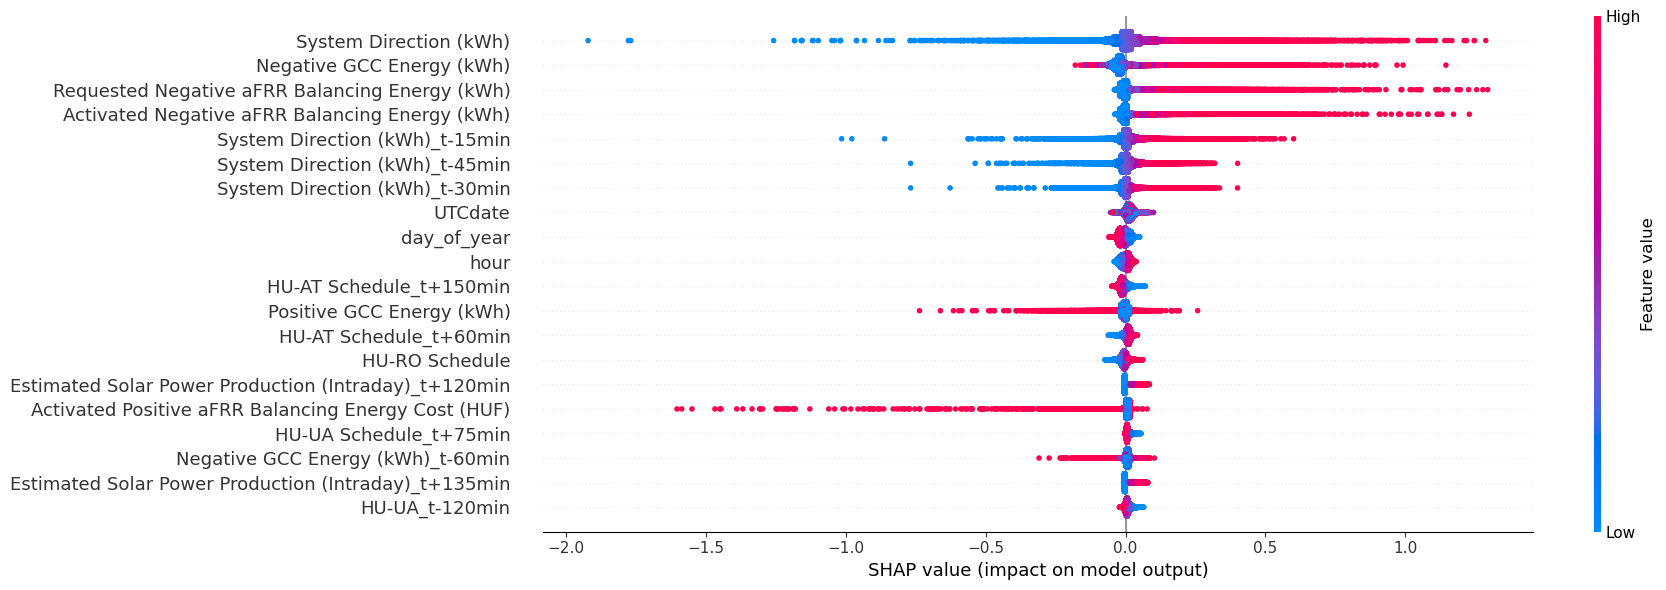

In [15]:
# Wider SHAP summary plots
for t in range(output_dim):
    print(f"\n=== SHAP Summary Plot for Target {y.columns[t]} ===")
    shap.summary_plot(
        shap_values_list[t],
        X_test_np_subset,
        feature_names=X.columns,
        show=True,
        plot_size=(18, 6)  # width x height in inches
    )


In [11]:
import re
import numpy as np

feature_names = X.columns
agg_shap_per_target = {}

for t, sv in enumerate(shap_values_list):
    mean_abs_sv = np.mean(np.abs(sv), axis=0)  # mean abs SHAP per feature

    # Step 1: Group variants by base name
    variants_dict = {}
    for i, fname in enumerate(feature_names):
        match = re.match(r"(.+)_t.*", fname)
        if match:
            base_name = match.group(1)
        else:
            base_name = fname
        if base_name not in variants_dict:
            variants_dict[base_name] = []
        variants_dict[base_name].append(mean_abs_sv[i])

    # Step 2: For each base feature, take top 5 variants and average
    agg_dict = {}
    for base_name, vals in variants_dict.items():
        top5_vals = sorted(vals, reverse=True)[:5]  # top 5
        agg_dict[base_name] = np.mean(top5_vals)

    # Step 3: Sort by SHAP descending
    agg_mean_abs_sv_sorted = dict(sorted(agg_dict.items(), key=lambda x: x[1], reverse=True))
    agg_shap_per_target[y.columns[t]] = agg_mean_abs_sv_sorted

# ---- Print results ----
for target_name, feat_dict in agg_shap_per_target.items():
    print(f"\n=== Target: {target_name} ===")
    for i, (feature, val) in enumerate(feat_dict.items()):
        print(f"{i+1:2d}. {feature}: {val:.5f}")
    top5_features = list(feat_dict.items())[:5]
    print(">>> Top 5 features (top 5 _t* averaged):", [f[0] for f in top5_features])



=== Target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min ===
 1. Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh): 0.04663
 2. Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh): 0.04096
 3. Negative GCC Energy (kWh): 0.03543
 4. day_of_year: 0.02202
 5. Requested Negative aFRR Balancing Energy (kWh): 0.01955
 6. Activated Negative aFRR Balancing Energy (kWh): 0.01879
 7. Positive GCC Energy (kWh): 0.01404
 8. Activated Positive aFRR Balancing Energy Cost (HUF): 0.01386
 9. HU-RO Schedule: 0.01265
10. HU-AT Schedule: 0.01096
11. Requested Positive aFRR Balancing Energy (kWh): 0.01037
12. dayofweek_cos: 0.00978
13. Gross System Load Forecast (Day-Ahead): 0.00961
14. Activated Positive aFRR Balancing Energy (kWh): 0.00927
15. HU-HR Schedule: 0.00915
16. Estimated Wind Power Production (Intraday): 0.00905
17. Solar Power Plants Net (Operational Control): 0.00887
18. HU-RS Schedule: 0.00789
19. HU-SK Schedule: 0.00776
20. Gross 

In [16]:
import csv
import pandas as pd

# Convert the aggregated SHAP dict to a DataFrame
# Rows = base features, Columns = targets, Values = SHAP values
all_base_features = set()
for feat_dict in agg_shap_per_target.values():
    all_base_features.update(feat_dict.keys())
all_base_features = sorted(all_base_features)

df_shap = pd.DataFrame(index=all_base_features, columns=y.columns)

for target_name, feat_dict in agg_shap_per_target.items():
    for feature in all_base_features:
        df_shap.loc[feature, target_name] = feat_dict.get(feature, 0.0)  # fill 0 if missing

# Save as CSV
df_shap.to_csv("shap_aggregated_top5.csv", float_format="%.5f")
print("Saved SHAP values to shap_aggregated_top5.csv")

# Optional: save as a human-readable TXT
with open("shap_aggregated_top5.txt", "w") as f:
    for target_name, feat_dict in agg_shap_per_target.items():
        f.write(f"=== Target: {target_name} ===\n")
        for i, (feature, val) in enumerate(feat_dict.items()):
            f.write(f"{i+1:2d}. {feature}: {val:.5f}\n")
        top5_features = list(feat_dict.items())[:5]
        f.write(">>> Top 5 features (top 5 _t* averaged): " + ", ".join([f[0] for f in top5_features]) + "\n\n")
print("Saved SHAP values to shap_aggregated_top5.txt")


Saved SHAP values to shap_aggregated_top5.csv
Saved SHAP values to shap_aggregated_top5.txt
